In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Загружаем метрики
metrics_df = pd.read_csv('../results/logs/model_comparison.csv')
print("📊 Финальные метрики:")
print(metrics_df.to_string(index=False))

📊 Финальные метрики:
       model  mAP@0.5  mAP@0.5:0.95  precision@0.5  recall@0.5   f1@0.5
 faster_rcnn 0.835758      0.545412       0.657485    0.933608 0.771587
         ssd 0.663735      0.377707       0.882816    0.750257 0.811157
efficientdet 0.763927      0.493838       0.705210    0.881240 0.783459
        detr 0.006868      0.002602       0.021384    0.220841 0.038992
        yolo 0.639910      0.386120       0.728000    0.572010 0.639910


In [6]:
# Красивая таблица
display_df = metrics_df.copy()
display_df.columns = ['Модель', 'mAP@0.5', 'mAP@0.5:0.95', 'Precision', 'Recall', 'F1']
display_df = display_df.round(4)
display_df

,Модель,mAP@0.5,mAP@0.5:0.95,Precision,Recall,F1
0,faster_rcnn,0.8358,0.5454,0.6575,0.9336,0.7716
1,ssd,0.6637,0.3777,0.8828,0.7503,0.8112
2,efficientdet,0.7639,0.4938,0.7052,0.8812,0.7835
3,detr,0.0069,0.0026,0.0214,0.2208,0.0390
4,yolo,0.6399,0.3861,0.7280,0.5720,0.6399


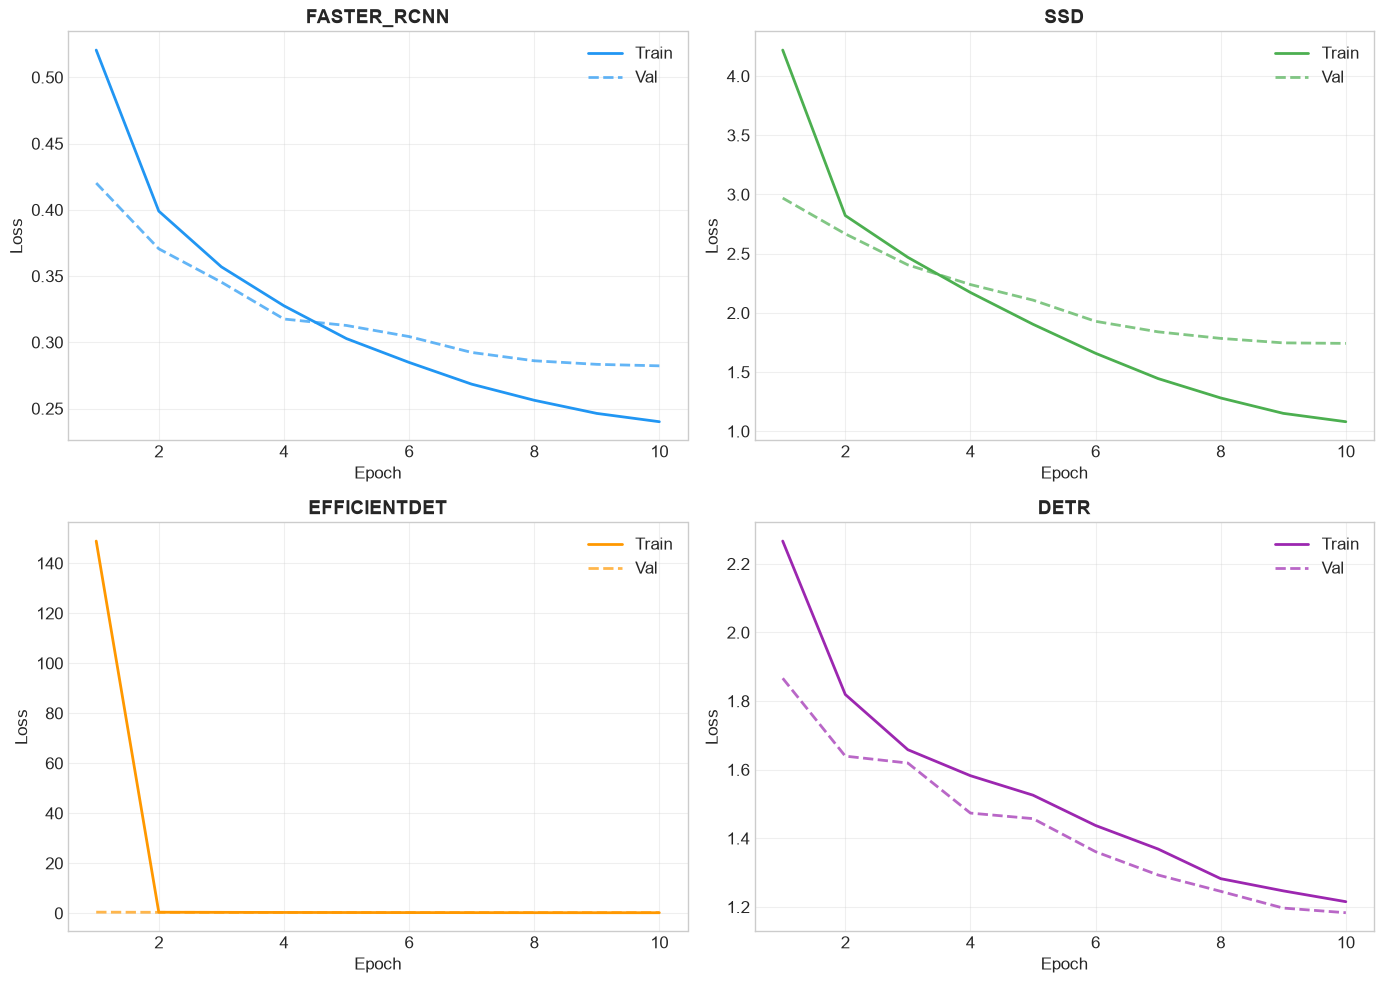

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

models = ['faster_rcnn', 'ssd', 'efficientdet', 'detr']
colors = {'faster_rcnn': '#2196F3', 'ssd': '#4CAF50', 
          'efficientdet': '#FF9800', 'detr': '#9C27B0'}

for idx, model in enumerate(models):
    df = pd.read_csv(f'../results/logs/{model}_training_log.csv')
    ax = axes[idx]
    ax.plot(df['epoch'], df['train_loss'], label='Train', color=colors[model], linewidth=2)
    ax.plot(df['epoch'], df['val_loss'], label='Val', color=colors[model], 
            linewidth=2, linestyle='--', alpha=0.7)
    ax.set_title(model.upper(), fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/plots/notebook_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

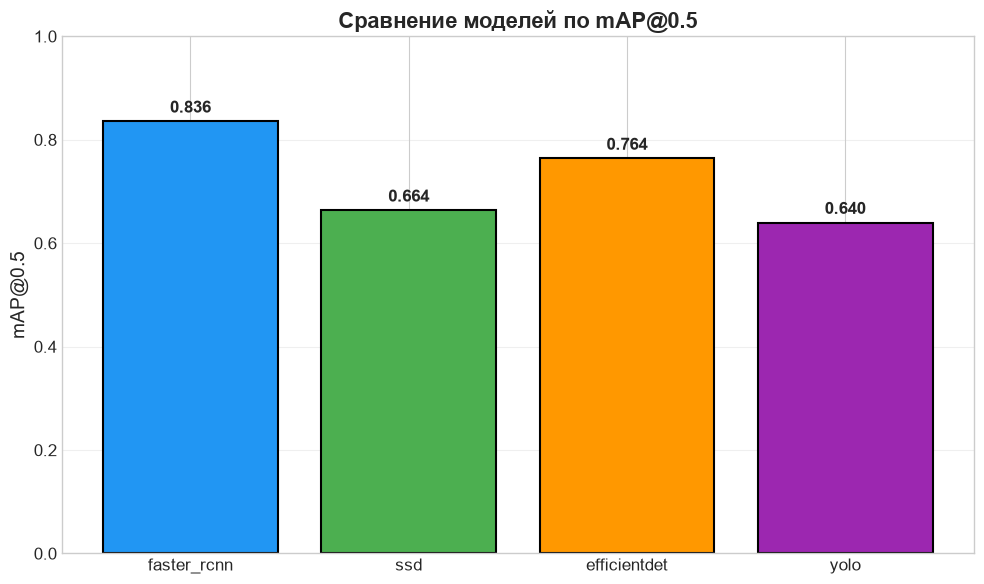

In [8]:
# Исключаем DETR для наглядности (можно включить обратно)
df_plot = metrics_df[metrics_df['model'] != 'detr'].copy()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(df_plot['model'], df_plot['mAP@0.5'], 
              color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'],
              edgecolor='black', linewidth=1.5)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('mAP@0.5', fontsize=14)
ax.set_title('Сравнение моделей по mAP@0.5', fontsize=16, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/plots/notebook_map_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

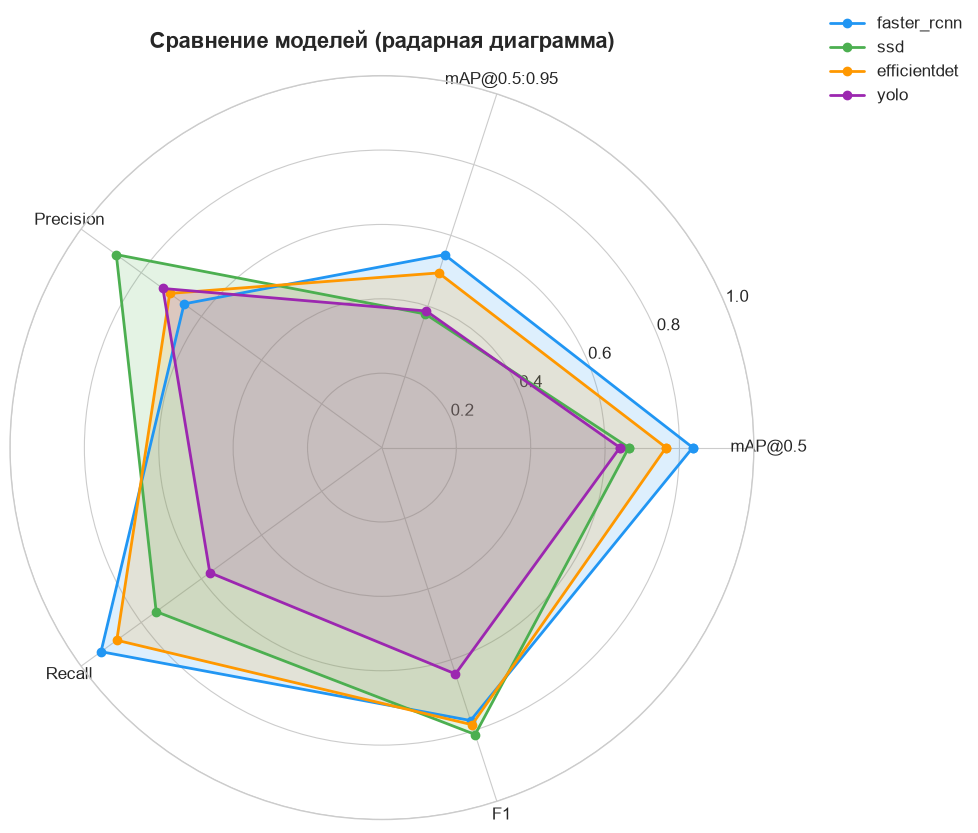

In [12]:
# Паукограмма для сравнения моделей
categories = ['mAP@0.5', 'mAP@0.5:0.95', 'Precision', 'Recall', 'F1']
N = len(categories)

# Углы
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

df_plot = metrics_df[metrics_df['model'] != 'detr'].copy()
colors_radar = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# ВАЖНО: используем enumerate для правильного индекса цвета
for color_idx, (df_idx, row) in enumerate(df_plot.iterrows()):
    values = [row['mAP@0.5'], row['mAP@0.5:0.95'], 
              row['precision@0.5'], row['recall@0.5'], row['f1@0.5']]
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, label=row['model'], color=colors_radar[color_idx])
    ax.fill(angles, values, alpha=0.15, color=colors_radar[color_idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 1)
ax.set_title('Сравнение моделей (радарная диаграмма)', 
             size=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12)

plt.tight_layout()
plt.savefig('../results/plots/notebook_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Время обучения
training_times = {
    'Faster R-CNN': {'epochs': 10, 'time_min': 20, 'params_M': 42},
    'SSD': {'epochs': 10, 'time_min': 15, 'params_M': 25},
    'RetinaNet': {'epochs': 10, 'time_min': 20, 'params_M': 34},
    'DETR': {'epochs': 10, 'time_min': 30, 'params_M': 41},
    'YOLOv8': {'epochs': 10, 'time_min': 10, 'params_M': 3}
}

df_time = pd.DataFrame(training_times).T
df_time.index.name = 'Модель'
df_time.columns = ['Эпох', 'Время (мин)', 'Параметры (M)']
print("⏱️ Время обучения и размер моделей:")
print(df_time.to_string())

⏱️ Время обучения и размер моделей:
              Эпох  Время (мин)  Параметры (M)
Модель                                        
Faster R-CNN    10           20             42
SSD             10           15             25
RetinaNet       10           20             34
DETR            10           30             41
YOLOv8          10           10              3
